# 0. Import Libraries

Pandas for tabular data, geopandas for spatial data
Pathlib for cross-platform file paths that don't break when you move folders

In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 1. Define Paths
Define the project root so paths work no matter where you run the script from
__file__ is the script's location; .parent goes up to scripts/, .parent again to 05-Code/

In [2]:
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    # Jupyter fallback: cwd is 05-Code, so go up one level to the project root
    BASE_DIR = Path(os.getcwd()).parent

RAW_DATA_DIR = BASE_DIR / 'data' / 'raw'

# 2. Convert Database from .dbf to .csv
Read trip microdata file (.dbf is a dBase database format used by legacy GIS/SPSS workflows)

In [3]:
dbf_path = RAW_DATA_DIR / 'Banco2023_divulgacao_190225.dbf'
od_sp_2023_dbf = gpd.read_file(dbf_path)

# Convert to CSV for faster reads later; geopandas preserves all attribute columns
# index=False avoids writing the row number as an extra column
csv_path = RAW_DATA_DIR / 'Banco2023_divulgacao_190225.csv'
od_sp_2023_dbf.to_csv(csv_path, index=False)

# 3. Read csv

In [4]:
od_sp_2023_csv = pd.read_csv(csv_path, low_memory=False)

# Clean names: strip whitespace, lowercase, replace spaces with underscores
# This prevents silent errors from columns like 'MOTIVO_D ' vs 'MOTIVO_D'
od_sp_2023_csv.columns = (
    od_sp_2023_csv.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
)

# Check columns data type in csv
# OD microdata mixes floats (distances, coordinates), ints (codes), and objects (strings)
# Knowing dtypes helps us spot whether ID columns were misread as numbers
print("--- CSV Dtypes ---")
print(od_sp_2023_csv.dtypes)

# Summarise csv data
print(f'Shape: {od_sp_2023_csv.shape}  ({od_sp_2023_csv.shape[0]:,} trips, {od_sp_2023_csv.shape[1]} columns)')
print(f'Memory: {od_sp_2023_csv.memory_usage(deep=True).sum() / 1e6:.1f} MB')

# describe() gives count/mean/std/min/max for numeric columns
# nunique() tells us how many distinct zones / modes / purposes exist
print("\n--- Numeric Summary ---")
print(od_sp_2023_csv.describe())

print("\n--- Cardinality (unique values per column) ---")
print(od_sp_2023_csv.nunique().sort_values(ascending=False).head(15))

--- CSV Dtypes ---
zona            int64
muni_dom        int64
co_dom_x        int64
co_dom_y        int64
id_dom        float64
               ...   
pe_bici         int64
tp_estbici      int64
prop_bici       int64
distancia     float64
id_ordem        int64
Length: 147, dtype: object
Shape: (143038, 147)  (143,038 trips, 147 columns)
Memory: 305.4 MB

--- Numeric Summary ---
                zona       muni_dom       co_dom_x      co_dom_y  \
count  143038.000000  143038.000000  143038.000000  1.430380e+05   
mean      259.282967      30.906598  334997.553706  7.392881e+06   
std       154.307916       9.337036   15967.858726  1.025606e+04   
min         1.000000       1.000000  281780.000000  7.345720e+06   
25%       115.000000      32.000000  324901.000000  7.386953e+06   
50%       262.000000      36.000000  332593.000000  7.393968e+06   
75%       399.000000      36.000000  344045.750000  7.398650e+06   
max       527.000000      39.000000  414075.000000  7.429361e+06   

      

In [5]:
# Visualise csv data

# First few rows
od_sp_2023_csv.head(10)

,zona,muni_dom,co_dom_x,co_dom_y,id_dom,f_dom,fe_dom,dom,cd_entre,data,...,duracao,modoprin,tipvg,tp_esauto,vl_est,pe_bici,tp_estbici,prop_bici,distancia,id_ordem
0,1,36,333725,7394554,NaN,1,32.34,1,1,2024-04-17,...,30,16,4,0,0,7,2,1,1518.60,1
1,1,36,333725,7394554,100001.0,0,32.34,1,1,2024-04-17,...,30,16,4,0,0,9,2,1,1518.60,2
2,1,36,333725,7394554,100002.0,1,32.34,2,1,2024-04-17,...,30,12,2,0,0,0,0,0,8350.07,3
3,1,36,333725,7394554,100002.0,0,32.34,2,1,2024-04-17,...,25,12,2,0,0,0,0,0,8350.07,4
4,1,36,333725,7394554,100002.0,0,32.34,2,1,2024-04-17,...,30,12,2,0,0,0,0,0,10346.38,5
5,1,36,333725,7394554,100002.0,0,32.34,2,1,2024-04-17,...,40,12,2,0,0,0,0,0,10346.38,6
6,1,36,333067,7394620,100003.0,1,32.34,3,1,2024-04-14,...,0,0,2,0,0,0,0,0,0.00,7
7,1,36,333067,7394620,100003.0,0,32.34,3,1,2024-04-14,...,0,0,2,0,0,0,0,0,0.00,8
8,1,36,333067,7394620,100003.0,0,32.34,3,1,2024-04-14,...,0,0,2,0,0,0,0,0,0.00,9
9,1,36,333067,7394620,100003.0,0,32.34,3,1,2024-04-14,...,26,4,1,0,0,0,0,0,2357.28,10


In [6]:
# All column names — compare against the data dictionary PDF
print(od_sp_2023_csv.columns.tolist())

['zona', 'muni_dom', 'co_dom_x', 'co_dom_y', 'id_dom', 'f_dom', 'fe_dom', 'dom', 'cd_entre', 'data', 'tipo_dom', 'agua', 'rua_pavi', 'no_morad', 'tot_fam', 'id_fam', 'f_fam', 'fe_fam', 'familia', 'no_moraf', 'condmora', 'qt_banho', 'qt_empre', 'qt_auto', 'qt_micro', 'qt_lavalou', 'qt_gel', 'qt_freez', 'qt_mlava', 'qt_dvd', 'qt_microon', 'qt_moto', 'qt_secarou', 'qt_bicicle', 'nao_dcl_it', 'criteriobr', 'ponto_br', 'ano_auto1', 'ano_auto2', 'ano_auto3', 'renda_fa', 'cd_renfa', 'id_pess', 'f_pess', 'fe_pess', 'pessoa', 'sit_fam', 'idade', 'sexo', 'ra_a', 'estuda', 'grau_ins', 'cd_ativi', 'co_ren_i', 'vl_ren_i', 'id_transp_', 'id_nao_uso', 'id_nao_us2', 'id_nao_us3', 'id_nao_us4', 'id_nao_us5', 'id_nao_us6', 'id_nao_us7', 'id_nao_us8', 'id_nao_us9', 'id_nao_u10', 'zona_esc', 'muniesc', 'co_esc_x', 'co_esc_y', 'tipo_esc', 'cd_pres_hi', 'cd_tipo_hi', 'qt_hibrido', 'zonatra1', 'munitra1', 'co_tr1_x', 'co_tr1_y', 'trab1_re', 'trabext1', 'ds_ocup_tr', 'setor1', 'vinc1', 'cd_pres_h2', 'cd_tipo_

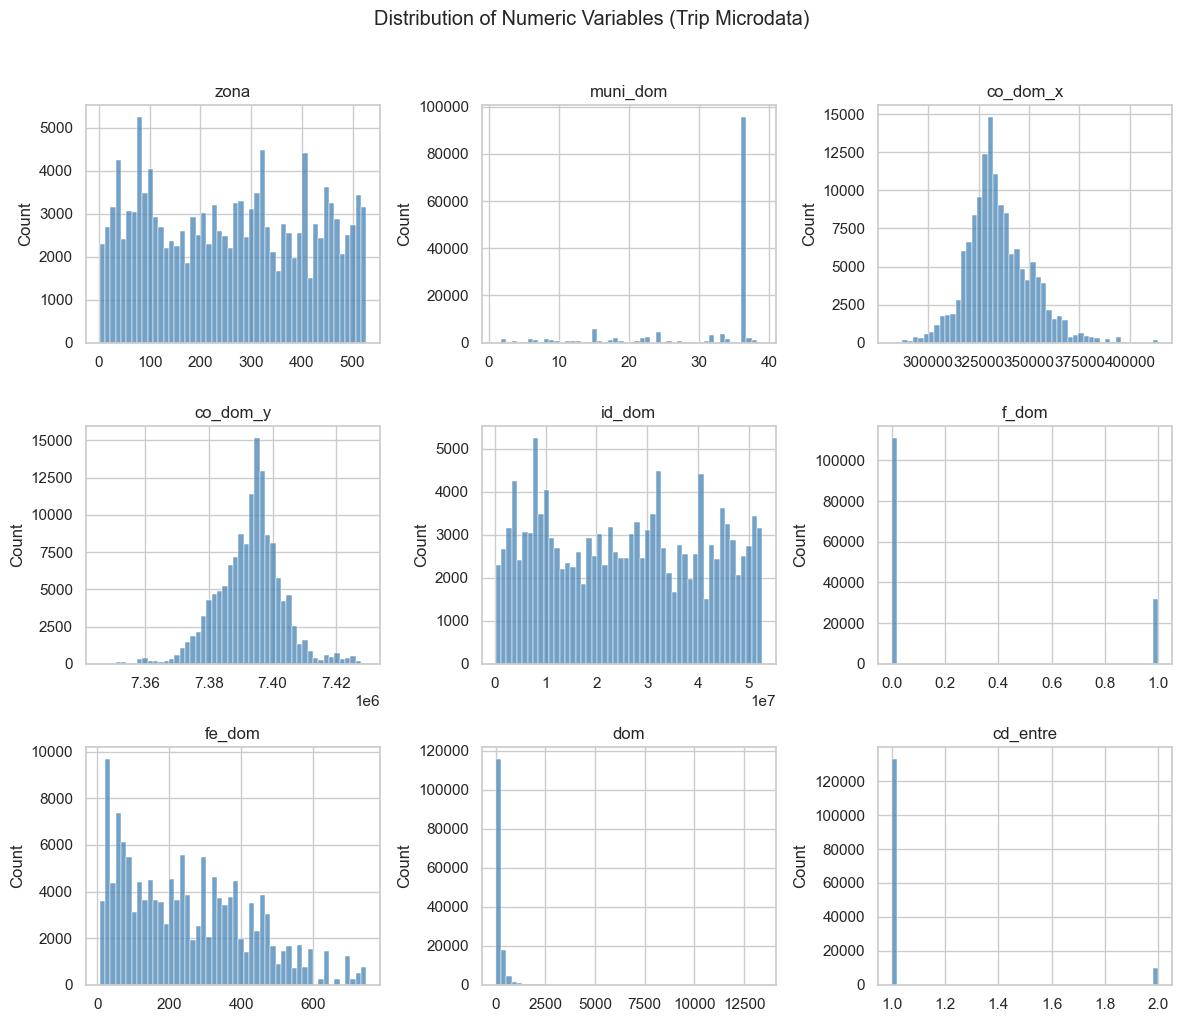

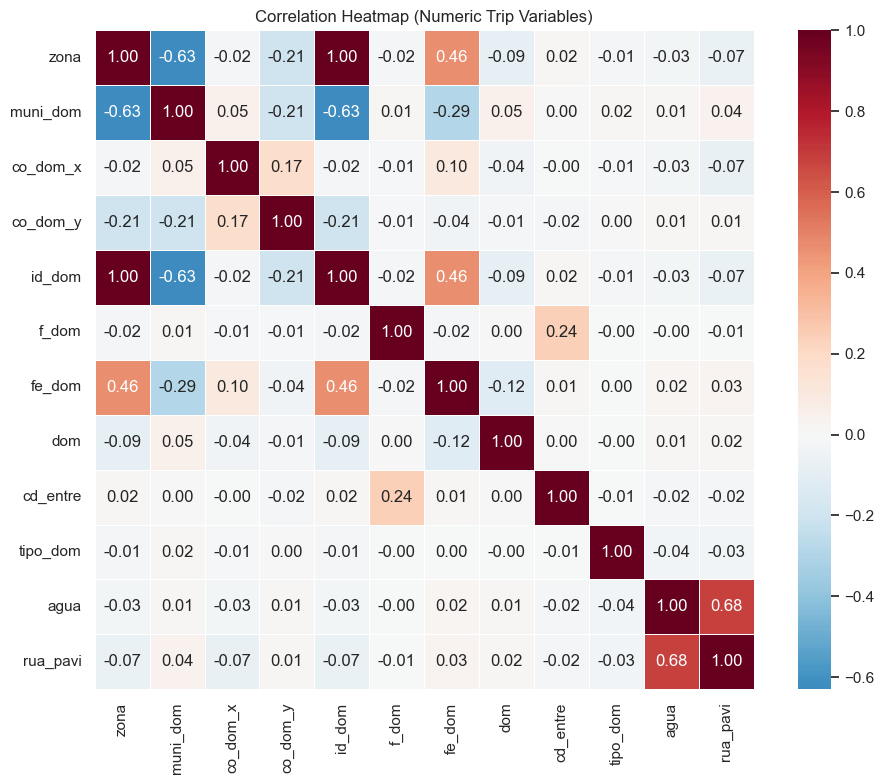

In [7]:
# Set a clean default style for all plots in this session
sns.set_theme(style='whitegrid')

# Select only numeric columns for plotting — the OD file has many categorical string codes
numeric_cols = od_sp_2023_csv.select_dtypes(include=['number']).columns.tolist()

# Drop coordinate/ID columns that aren't meaningful distributions
# Adjust this list after you run the dtype check above if your column names differ
cols_to_skip = ['coord_x_o', 'coord_y_o', 'coord_x_d', 'coord_y_d', 'zonao', 'zonad']
plot_cols = [c for c in numeric_cols if c not in cols_to_skip]

# Distribution of numeric variables
# Histograms let us spot skewed travel times, extreme distances, or zero-inflation
# We cap at 9 subplots (3×3) to keep the figure readable; add more later if needed
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols[:9]):
    sns.histplot(od_sp_2023_csv[col], bins=50, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')

# Remove empty subplots if we have fewer than 9 columns to plot
for ax in axes[len(plot_cols[:9]):]:
    ax.set_visible(False)

plt.suptitle('Distribution of Numeric Variables (Trip Microdata)', y=1.02)
plt.tight_layout()
plt.show()

# Correlation heatmap (numeric columns only)
# This shows which numeric attributes move together — e.g., trip duration vs. distance
# We keep only a subset of interpretable columns so the heatmap isn't crowded
heatmap_cols = [c for c in plot_cols if c in plot_cols[:12]]
corr = od_sp_2023_csv[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap (Numeric Trip Variables)')
plt.tight_layout()
plt.show()

# 4. Wrangling csv

In [8]:
# Create the clean output folder if it doesn't exist 
CLEAN_DATA_DIR = BASE_DIR / 'data' / 'clean'
CLEAN_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Filter to trips where BOTH origin AND destination are in São Paulo municipality
# Municipality code 36 = São Paulo city proper. This excludes trips from/to the metro region.
df = od_sp_2023_csv.copy()
df = df[(df['muni_o'] == 36) & (df['muni_d'] == 36)].copy()
print(f"Rows after muni_o == 36 AND muni_d == 36: {len(df):,}")

# Keep only working-age passengers (18 to 65 inclusive)
df = df[(df['idade'] >= 18) & (df['idade'] <= 65)].copy()
print(f"Rows after age filter (18–65): {len(df):,}")

Rows after muni_o == 36 AND muni_d == 36: 72,815
Rows after age filter (18–65): 52,332


In [9]:
# Filter anchors and include chained trips 
# Anchors = long-permanence activities at the origin (residence, work, study).
# OD SP 2023 purpose codes: 1)Work in industry, 2)Work in commerce, 3)Work in services, 4)School/Education, 8)Residence
# Also keep intermediate trips that are linked between two anchors (include chaining trips)

ANCHOR_PURPOSES = {1, 2, 3, 4, 8}

# The OD survey uses a person ID and a trip sequence number to order each person's day.
person_id_col = 'id_pess'
trip_seq_col  = 'n_viag'

# Legend mapping for MOTIVO_O (and MOTIVO_D)
purpose_labels = {
    1:  "Work in industry",
    2:  "Work in commerce",
    3:  "Work in services",
    4:  "School/Education",
    5:  "Shopping",
    6:  "Doctor/Dentist/Health",
    7:  "Recreation/Visits/Leisure",
    8:  "Residence",
    9:  "Job search",
    10: "Personal Matters",
    11: "Dining"
}

# --- Build filtered dataframe manually (avoids groupby.apply() KeyError) ---
filtered_chunks = []

for person_id, person_trips in df.groupby(person_id_col, sort=False):
    # sort this person's trips by trip sequence number
    person_trips = person_trips.sort_values(trip_seq_col).reset_index(drop=True)
    n = len(person_trips)
    keep = np.zeros(n, dtype=bool)
    
    # Rule A: keep all trips that originate at an anchor activity
    is_anchor_o = person_trips['motivo_o'].isin(ANCHOR_PURPOSES).values
    keep[is_anchor_o] = True
    
    # Rule B: walk through the day and mark completed chains
    in_chain = False
    buffer = []
    
    for i in range(n):
        if is_anchor_o[i]:
            # Leaving an anchor starts a potential chain
            in_chain = True
            buffer = [i]
        elif in_chain:
            buffer.append(i)
            if person_trips['motivo_d'].iloc[i] in ANCHOR_PURPOSES:
                # Chain closes at an anchor destination — keep every trip in between
                for idx in buffer:
                    keep[idx] = True
                in_chain = False
                buffer = []
        # else: trip is standalone and not an anchor origin → discard
    
    person_trips['keep'] = keep
    filtered_chunks.append(person_trips)

# Reassemble and filter
df = pd.concat(filtered_chunks, ignore_index=True)
df = df[df['keep']].drop(columns='keep').copy()

print(f"Rows after anchor + chain filter: {len(df):,}")

# --- User and trip summary -------------------------------------------------
raw_users      = df['id_pess'].nunique()
expanded_users = df.groupby('id_pess')['fe_pess'].first().sum()
raw_trips      = len(df)
expanded_trips = df['fe_via'].sum()

print("\n=== User and trip summary ===")
print(f"Unique users (raw):             {raw_users:,}")
print(f"Unique users (expanded):        {expanded_users:,.1f}")
print(f"Total trips (raw):              {raw_trips:,}")
print(f"Total trips (expanded):         {expanded_trips:,.1f}")
print(f"Mean trips per user (raw):      {raw_trips / raw_users:.2f}")
print(f"Mean trips per user (expanded): {expanded_trips / expanded_users:.2f}")

# --- Purpose at origin (motivo_o) in filtered data -----------------------
print("\n=== Purpose at origin (motivo_o) in filtered data ===")
print(f"{'Code':<5} {'Label':<30} {'Raw count':>12} {'Expanded (fe_via)':>18}")
print("-" * 68)

counts   = df['motivo_o'].value_counts().sort_index()
expanded = df.groupby('motivo_o')['fe_via'].sum().sort_index()

for code in counts.index:
    label = purpose_labels.get(code, "Unknown")
    print(f"{code:<5} {label:<30} {counts[code]:>12,} {expanded[code]:>18,.1f}")

print("-" * 68)
print(f"{'Total':<5} {'':30} {counts.sum():>12,} {expanded.sum():>18,.1f}")

Rows after anchor + chain filter: 52,252

=== User and trip summary ===
Unique users (raw):             21,984
Unique users (expanded):        4,817,930.8
Total trips (raw):              52,252
Total trips (expanded):         13,724,446.8
Mean trips per user (raw):      2.38
Mean trips per user (expanded): 2.85

=== Purpose at origin (motivo_o) in filtered data ===
Code  Label                             Raw count  Expanded (fe_via)
--------------------------------------------------------------------
1     Work in industry                      1,312          405,198.8
2     Work in commerce                      3,244          923,818.7
3     Work in services                     11,989        3,147,489.6
4     School/Education                      5,069        1,353,046.2
5     Shopping                              1,293          290,126.1
6     Doctor/Dentist/Health                 1,135          301,838.3
7     Recreation/Visits/Leisure             1,376          267,955.2
8     Resid

# 5. Save the analysis-ready subset 

In [10]:
clean_path = CLEAN_DATA_DIR / 'od_2023_sp_clean.csv'
df.to_csv(clean_path, index=False)
print(f"\nClean filtered dataset saved to: {clean_path}")
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Clean filtered dataset saved to: /Users/beatrizwerneck/Documents/URBAN_SPATIAL_SCIENCES/CASA0004_Urban_Spatial_Science_Dissertation/05-Code/data/clean/od_2023_sp_clean.csv
Final shape: 52,252 rows × 147 columns


# 6. Read and prepare zone shapefile

In [11]:
# Read shapefile with OD zone polygons.
zones_shp = gpd.read_file(
    RAW_DATA_DIR / '002_Site Metro Mapas_190225' / 'Shape' / 'Zonas_2023.shp'
)

# Clean names to match the CSV style (lowercase, no spaces)
zones_shp.columns = (
    zones_shp.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
)

# Verify CRS
zones_shp.crs


# Create a WGS84 copy for downstream spatial joins with OSM / R5.
# OSM amenities, road network and GTFS all use EPSG:4326.
# R5/r5py also requires origin coordinates as lat/lon.
zones_shp_4326 = zones_shp.to_crs(epsg=4326)

In [12]:
# Check columns and geometry
print("\n--- SHP CRS ---")
print(zones_shp.crs)

print("\n--- SHP Dtypes ---")
print(zones_shp.dtypes)


--- SHP CRS ---
EPSG:22523

--- SHP Dtypes ---
numerozona       int32
nomezona        object
numeromuni       int32
nomemunici      object
numdistrit       int32
nomedistri      object
area_ha_2      float64
geometry      geometry
dtype: object


In [13]:
# Area is safe to calculate because EPSG:22523 is metric (metres)
zones_shp['area_m2'] = zones_shp.geometry.area

print("\n--- Shapefile Numeric Summary ---")
print(zones_shp.drop(columns='geometry').describe())

print("\n--- Zone count and total area ---")
print(f"Number of zones: {len(zones_shp)}")
print(f"Total area (km²): {zones_shp['area_m2'].sum() / 1e6:.1f}")


--- Shapefile Numeric Summary ---
       numerozona  numeromuni  numdistrit     area_ha_2       area_m2
count  527.000000  527.000000  527.000000    527.000000  5.270000e+02
mean   264.000000   30.337761   71.893738   1511.372391  1.507698e+07
std    152.276065   10.223164   39.441540   3515.368370  3.506677e+07
min      1.000000    1.000000    1.000000     31.030000  3.095684e+05
25%    132.500000   26.500000   36.000000    198.495000  1.980278e+06
50%    264.000000   36.000000   74.000000    367.700000  3.667995e+06
75%    395.500000   36.000000  109.000000    907.260000  9.051554e+06
max    527.000000   80.000000  134.000000  28967.460000  2.888369e+08

--- Zone count and total area ---
Number of zones: 527
Total area (km²): 7945.6


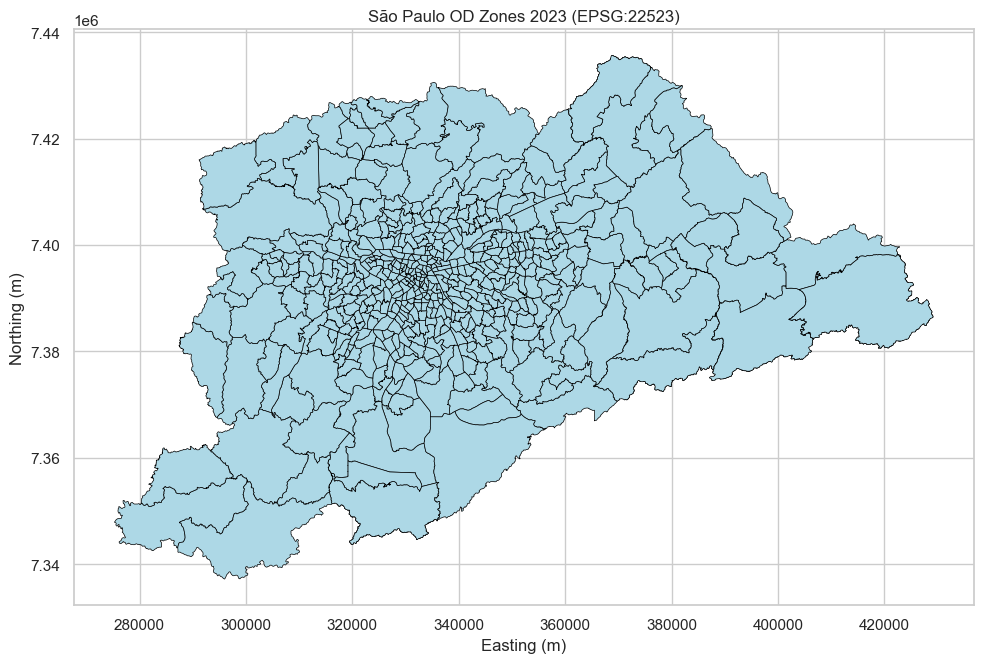

In [14]:
# Visualise
fig, ax = plt.subplots(figsize=(10, 10))
zones_shp.plot(ax=ax, edgecolor='black', facecolor='lightblue', linewidth=0.5)
ax.set_title('São Paulo OD Zones 2023 (EPSG:22523)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# 7. Wrangling shp file

In [15]:
# Filter to SP municipality
# numeromuni == 36 is São Paulo municipality proper
zones_sp = zones_shp[zones_shp['numeromuni'] == 36].copy()
zones_sp_4326 = zones_shp_4326[zones_shp_4326['numeromuni'] == 36].copy()

print(f"Zones in São Paulo municipality: {len(zones_sp)} (from {len(zones_shp)} total)")

Zones in São Paulo municipality: 343 (from 527 total)


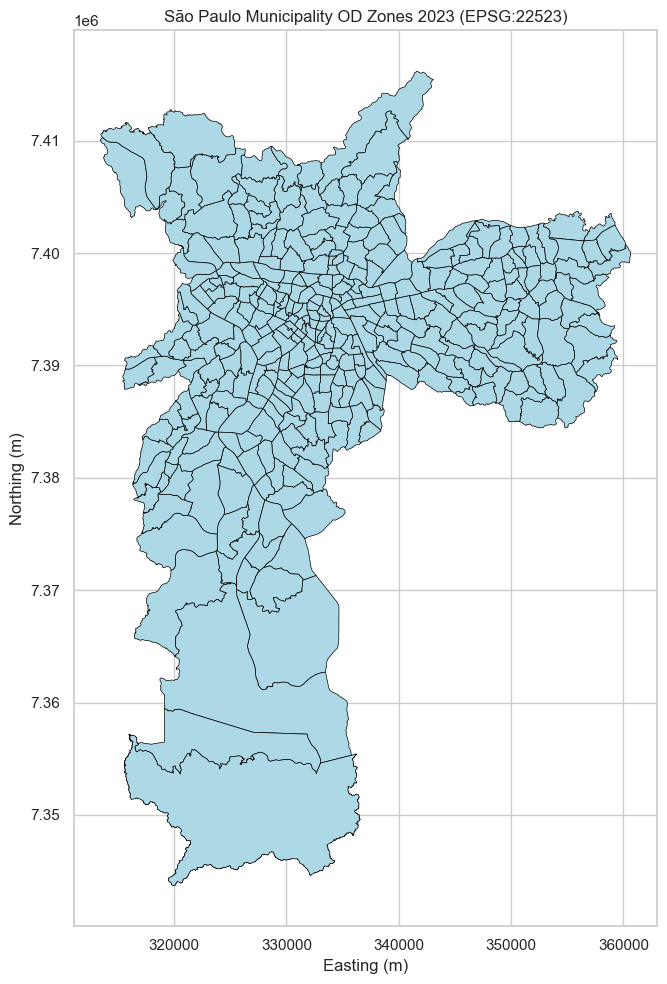

In [18]:
# Visualise
fig, ax = plt.subplots(figsize=(10, 10))
zones_sp.plot(ax=ax, edgecolor='black', facecolor='lightblue', linewidth=0.5)
ax.set_title('São Paulo Municipality OD Zones 2023 (EPSG:22523)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# 8. Save the analysis-ready subset geopackage

Metric version: for internal OD work (area, density, zone-level aggregations)
clean_zones_path = CLEAN_DATA_DIR / 'zonas_sp_municipio_2023.gpkg'
zones_sp.to_file(clean_zones_path, driver='GPKG')
print(f"Clean zones (EPSG:22523) saved to: {clean_zones_path}")

WGS84 version: for OSM / R5 spatial joins later
clean_zones_4326_path = CLEAN_DATA_DIR / 'zonas_sp_municipio_2023_4326.gpkg'
zones_sp_4326.to_file(clean_zones_4326_path, driver='GPKG')
print(f"Clean zones (EPSG:4326) saved to: {clean_zones_4326_path}")

# 9. Georeference trip origins from the cleaned CSV

The CSV coordinates (co_o_x, co_o_y) are in the same metric CRS as the zones.
We build a GeoDataFrame explicitly in EPSG:22523, then derive lat/lon for r5py.

In [16]:
# Create point objects from coords
gdf_origins = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['co_o_x'], df['co_o_y']),
    crs='EPSG:22523'
)

# Reproject the points to WGS EPSG:4326
gdf_origins_4326 = gdf_origins.to_crs(epsg=4326)
# Pull the lat/lon back into the table as simple columns
df['lat_o'] = gdf_origins_4326.geometry.y
df['lon_o'] = gdf_origins_4326.geometry.x

# 10. Save a parquet file with all the geometry transformations

In [17]:
trips_path = CLEAN_DATA_DIR / 'trips_sp_enriched.parquet'

# Force all columns into plain numpy-compatible dtypes.
# PyArrow sometimes fails on pandas ExtensionDtypes (e.g. string[pyarrow], nullable Int64).
df_save = pd.DataFrame()
for col in df.columns:
    if pd.api.types.is_integer_dtype(df[col]):
        df_save[col] = df[col].astype('int64')
    elif pd.api.types.is_float_dtype(df[col]):
        df_save[col] = df[col].astype('float64')
    else:
        # All remaining columns (strings, categoricals, etc.) → plain strings
        df_save[col] = df[col].astype('str')

df_save.to_parquet(trips_path, index=False)
print(f"\nEnriched trips saved to: {trips_path}")
print(f"Rows: {len(df_save):,} | CRS of metric coords: EPSG:22523 | CRS of lat/lon: EPSG:4326")


# %%[markdown]
# Now the DataFrame df carries both versions:
# - co_o_x and co_o_y in metres (EPSG:22523). These stay aligned with the zones and are good for distance calculations.
# - lat_o and lon_o in degrees (EPSG:4326). These are ready for R5 and OSM.

# The routing script later does not need to think about projections at all. 
# It just opens the file and feeds lat_o / lon_o to R5.

/var/folders/5c/r0_yx13921l4ssx0fl4y53zw0000gn/T/ipykernel_7784/1379620673.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_save[col] = df[col].astype('int64')
/var/folders/5c/r0_yx13921l4ssx0fl4y53zw0000gn/T/ipykernel_7784/1379620673.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_save[col] = df[col].astype('int64')
/var/folders/5c/r0_yx13921l4ssx0fl4y53zw0000gn/T/ipykernel_7784/1379620673.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whi


Enriched trips saved to: /Users/beatrizwerneck/Documents/URBAN_SPATIAL_SCIENCES/CASA0004_Urban_Spatial_Science_Dissertation/05-Code/data/clean/trips_sp_enriched.parquet
Rows: 52,252 | CRS of metric coords: EPSG:22523 | CRS of lat/lon: EPSG:4326
